How to use this notebook:

1. Shot with NO LIGHT with different exposure time. Take down t and write into *time* array. For EACH exposure time, 30 frames is recommanded. 
   
2. The codes will first calculate the time-domain average and standard variation for EACH t and 2 single frames is obtained for EACH t. They are put into 2 arrays (*I_img_stack*; *sigma_img_stack*).
   
3. Then the values are averaged in space-domain to become 2 value arrays (*I_stack*, *sigma_stack*).
   
4. **Offset** and **readout noise** are decided by ultra-low exposure time data, which is defined by *avg_num*. If *avg_num*=4, then the first 4 value of *I_stack* and *sigma_stack* will be used for calculation.
   
5. The arrays are plotted against *time* to show the relationship. The intensity (*dark_curent*, whose offset is substacted) should be propotional to time, while noise should show a 1/2-power dependence. Further fitting is performed on points excluding those used for offset calculation.
   
6. **gain** should be set manually to transform DN to e-. One may calculate them in PTC experiment. 

## Calculate Dark Current

In [1]:
import os
import numpy as np
import tifffile as tiff
from funcs import * 

In [20]:
names_dark = ['10us','100us','1ms','10ms','100ms','200ms','500ms','1000ms','2000ms','3000ms']
time = [10e-3,100e-3,1,10,100,200,500,1000,2000,3000] # ms
folder_path = '/Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_' 
dark_paths = [(folder_path + name) for name in names_dark]

In [21]:
I_img_stack = []
sigma_img_stack = []
for name in dark_paths:
    print("Processing from: "+name)
    I_img, sigma_img = time_average_all_tif(name) 
    I_img_stack.append(I_img) # 所有像素的平均值
    sigma_img_stack.append(sigma_img)

Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_10us
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_100us
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_1ms
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_10ms
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_100ms
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_200ms
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_500ms
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Dark_1000ms
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/D

In [22]:
I_stack = []
sigma_stack = []
for I in I_img_stack:
    I_stack.append(np.mean(I))
    print(np.mean(I))
for sigma in sigma_img_stack:
    sigma_stack.append(np.mean(sigma))
    print(np.mean(sigma))

1642.5443
1640.4282
1638.2355
1636.9487
1639.766
1641.508
1650.7839
1664.739
1691.0343
1713.843
32.228382
32.215927
32.123188
32.25471
32.325134
32.373203
32.648144
33.10783
33.69034
34.44709


In [23]:
avg_num = 4
offset = np.mean(I_stack[:avg_num])
readout_noise = np.mean(sigma_stack[:avg_num])

sigma_array = np.array(sigma_img_stack[:avg_num])
sigma_mean = np.mean(sigma_array, axis=0)
sigma_median = np.median(sigma_mean)  # 所有像素噪声平均值的中位数
sigma_rms = np.sqrt(np.mean(sigma_mean**2))
print(f"  噪声中位数: {sigma_median:.4f}")
print(f"  噪声RMS: {sigma_rms:.4f}")

  噪声中位数: 31.3894
  噪声RMS: 32.5611


In [24]:
dark_curent = np.array(I_stack)-np.array(offset)
log_dark_current = np.log(dark_curent[avg_num:])
dark_curent_noise = np.sqrt(np.square(sigma_stack)-np.square(readout_noise))
log_sigma = np.log(dark_curent_noise[avg_num:])
offset, readout_noise

/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_10433/3456772237.py:3: RuntimeWarning: invalid value encountered in sqrt
  dark_curent_noise = np.sqrt(np.square(sigma_stack)-np.square(readout_noise))


(1639.5392, 32.20555)

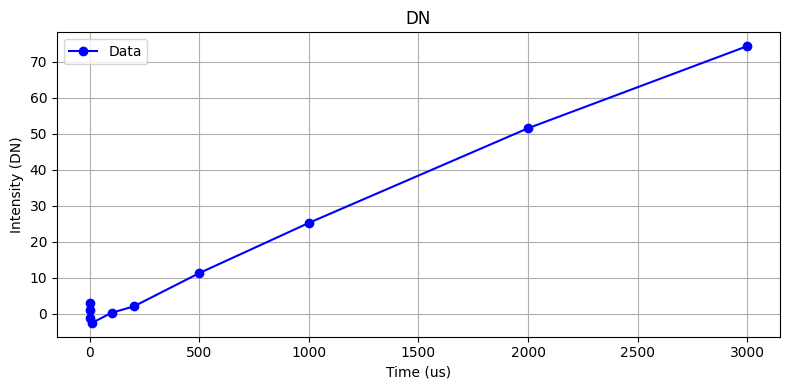

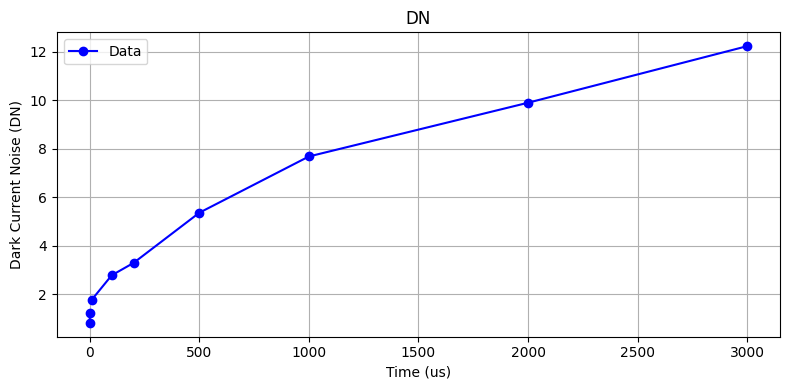

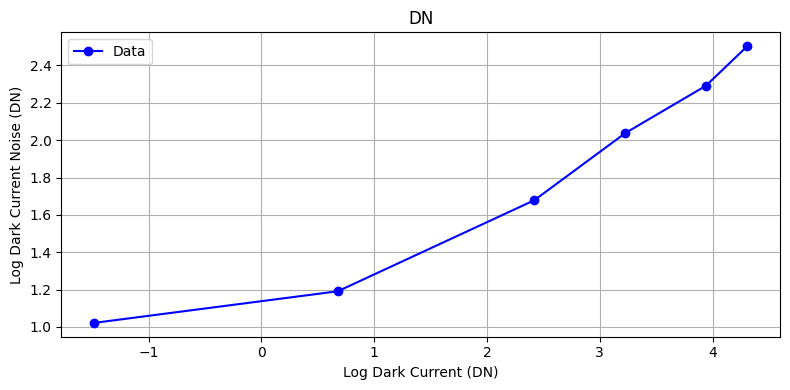

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(time, dark_curent, marker='o', linestyle='-', color='blue', label='Data')
# 标签与标题
plt.xlabel("Time (us)")
plt.ylabel("Intensity (DN)")
plt.title("DN")
plt.legend()
plt.grid(True)
# 显示
plt.tight_layout()

plt.figure(figsize=(8, 4))
plt.plot(time, dark_curent_noise, marker='o', linestyle='-', color='blue', label='Data')
# 标签与标题
plt.xlabel("Time (us)")
plt.ylabel("Dark Current Noise (DN)")
plt.title("DN")
plt.legend()
plt.grid(True)
# 显示
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(log_dark_current, log_sigma, marker='o', linestyle='-', color='blue', label='Data')
# 标签与标题
plt.xlabel("Log Dark Current (DN)")
plt.ylabel("Log Dark Current Noise (DN)")
plt.title("DN")
plt.legend()
plt.grid(True)
# 显示
plt.tight_layout()
plt.show()

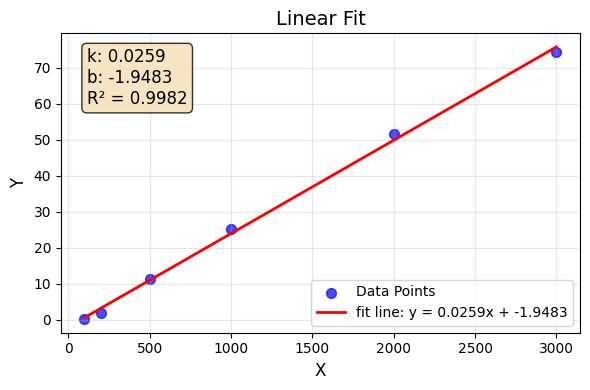

In [26]:
k, b, r_squared = linear_fit_plot(time[avg_num:], dark_curent[avg_num:], xlabel='X', ylabel='Y', title='Linear Fit')

In [27]:
gain = 1.4788 # DN/e
dark_current_per_sec_e = k/gain # e/time
readout_noise_e = readout_noise/gain
sigma_median_e = sigma_median/gain
sigma_rms_e = sigma_rms/gain
print("Avg readout noise of this camera is:"+str(readout_noise_e)+" e-")
print("Medium readout noise of this camera is:"+str(sigma_median_e)+" e-")
print("Medium readout noise of this camera is:"+str(sigma_rms_e)+" e-")
print("Dark current of this camera is:"+str(dark_current_per_sec_e)+" e-/microsecond (e-/ms)")
sigma_median_e = sigma_median/gain
sigma_rms_e = sigma_rms/gain

Avg readout noise of this camera is:21.778165504098553 e-
Medium readout noise of this camera is:21.226235199593713 e-
Medium readout noise of this camera is:22.018614220303203 e-
Dark current of this camera is:0.017515085081567523 e-/microsecond (e-/ms)
